In [135]:
# SimPEG functionality
import torch
from SimPEG.config import SimpegConfig
from SimPEG.electromagnetics.static import resistivity as dc
from SimPEG.utils import model_builder
from SimPEG.utils.io_utils.io_utils_electromagnetics import write_dcip2d_ubc
from SimPEG import maps, data
from SimPEG.electromagnetics.static.utils.static_utils import (
    generate_dcip_sources_line,
    pseudo_locations,
    plot_pseudosection,
    apparent_resistivity_from_voltage,
)

# discretize functionality
from discretize import TreeMesh
from discretize.utils import active_from_xyz

# Common Python functionality
import os
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

mpl.rcParams.update({"font.size": 14})  # default font size

write_output = False  # Optional


In [136]:
# Along-line locations
x_topo = np.linspace(-2000, 2000, 401)

# Elevation as a function of along-line location
T = 800.0
z_topo = 20.0 * np.sin(2 * np.pi * x_topo / T) + 140.0
z_topo[x_topo < -3 * T / 4] = 160.0
z_topo[x_topo > 3 * T / 4] = 120.0
z_topo += 50.0 * (1.0 + np.tanh(-3 * (x_topo + 1200.0) / T))
z_topo -= 50.0 * (1.0 + np.tanh(3 * (x_topo - 1200.0) / T))

# Define full 2D topography
topo_2d = np.c_[x_topo, z_topo]


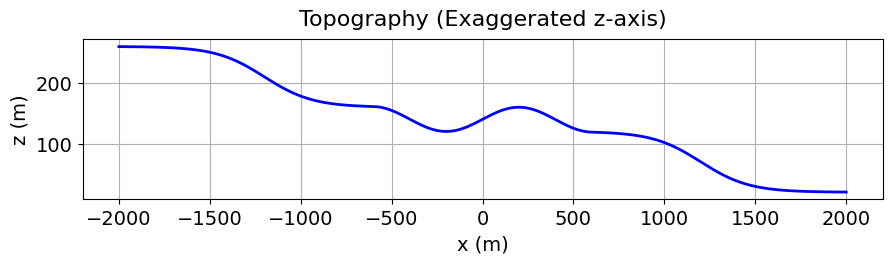

In [137]:
# Plot 2D topography
fig = plt.figure(figsize=(10, 2))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot(x_topo, z_topo, color="b", linewidth=2)
ax.set_xlabel("x (m)", labelpad=5)
ax.set_ylabel("z (m)", labelpad=5)
ax.grid(True)
ax.set_title("Topography (Exaggerated z-axis)", fontsize=16, pad=10)
plt.show(fig)


In [138]:
# Define survey line parameters
survey_type = "dipole-dipole"
dimension_type = "2D"
data_type = "volt"
end_locations = np.r_[-400.0, 400.0]  # along-line position
station_separation = 40.0
num_rx_per_src = 10


In [139]:
# Define linear interpolation function for elevation
interp_fun = interp1d(x_topo, z_topo)


In [140]:
# Define electrode locations
electrode_locations_x = np.arange(
    end_locations[0], end_locations[1] + station_separation, station_separation
)
electrode_locations_z = interp_fun(electrode_locations_x)
electrode_locations = np.c_[electrode_locations_x, electrode_locations_z]

# Number of electrode locations
n_electrodes = len(electrode_locations_x)


In [141]:
# Instantiate empty list for sources
source_list = []

ii = 0
while ii < n_electrodes - 3:
    # A and B electrode locations
    location_a = electrode_locations[ii, :]
    location_b = electrode_locations[ii + 1, :]

    # M and N electrode locations
    ii_max = np.min([ii + 3 + num_rx_per_src, n_electrodes])
    locations_m = electrode_locations[ii + 2 : ii_max - 1]
    locations_n = electrode_locations[ii + 3 : ii_max]

    # Define receivers for source ii
    receivers_list = [
        dc.receivers.Dipole(
            locations_m=locations_m, locations_n=locations_n, data_type=data_type
        )
    ]

    # Append source ii to list
    source_list.append(
        dc.sources.Dipole(receivers_list, location_a=location_a, location_b=location_b)
    )

    ii += 1

# Define survey
survey = dc.Survey(source_list)


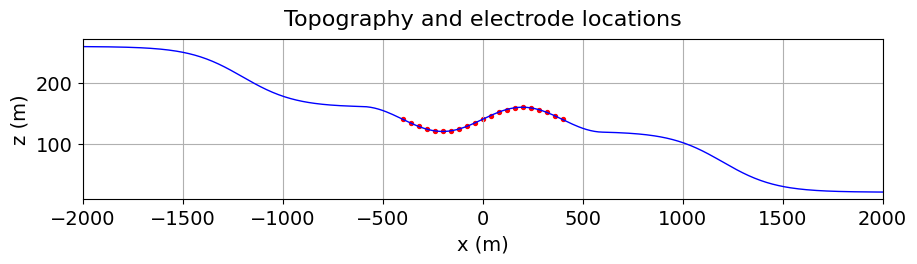

In [142]:
fig = plt.figure(figsize=(10, 2))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot(x_topo, z_topo, color="b", linewidth=1)
ax.scatter(electrode_locations_x, electrode_locations_z, 8, "r")
ax.set_xlim([x_topo.min(), x_topo.max()])
ax.set_xlabel("x (m)", labelpad=5)
ax.set_ylabel("z (m)", labelpad=5)
ax.grid(True)
ax.set_title("Topography and electrode locations", fontsize=16, pad=10)
plt.show(fig)


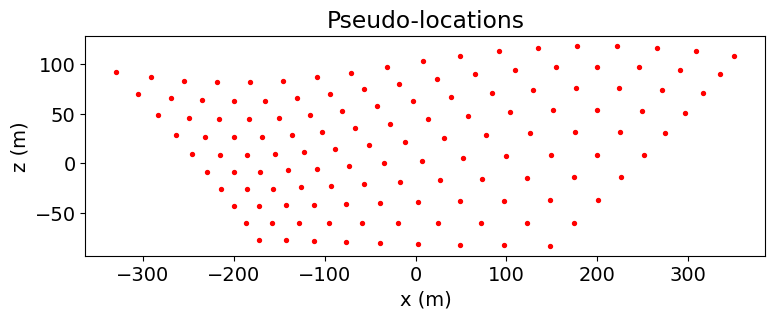

In [143]:
pseudo_locations_xz = pseudo_locations(survey)
fig = plt.figure(figsize=(8, 2.75))
ax = fig.add_axes([0.1, 0.1, 0.85, 0.8])
ax.scatter(pseudo_locations_xz[:, 0], pseudo_locations_xz[:, -1], 8, "r")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.set_title("Pseudo-locations")
plt.show()


In [144]:
dh = 4  # base cell width
dom_width_x = 3200.0  # domain width x
dom_width_z = 2400.0  # domain width z
nbcx = 2 ** int(np.round(np.log(dom_width_x / dh) / np.log(2.0)))  # num. base cells x
nbcz = 2 ** int(np.round(np.log(dom_width_z / dh) / np.log(2.0)))  # num. base cells z

# Define the base mesh with top at z = 0 m.
hx = [(dh, nbcx)]
hz = [(dh, nbcz)]
mesh = TreeMesh([hx, hz], x0="CN", diagonal_balance=True)

# Shift top to maximum topography
mesh.origin = mesh.origin + np.r_[0.0, z_topo.max()]

# Mesh refinement based on topography
mesh.refine_surface(
    topo_2d,
    padding_cells_by_level=[0, 0, 4, 4],
    finalize=False,
)

# Extract unique electrode locations.
unique_locations = survey.unique_electrode_locations

# Mesh refinement near electrodes.
mesh.refine_points(
    unique_locations, padding_cells_by_level=[8, 12, 6, 6], finalize=False
)

mesh.finalize()


In [145]:
print("# of cells: {}".format(mesh.n_cells))  # Number of cells
print("# of x-faces: {}".format(mesh.n_faces_x))  # Number of x-faces
print("Origin: {}".format(mesh.origin))  # bottom-southewest corner
print("Max cell volume: {}".format(mesh.cell_volumes.max()))  # Largest cell size
print(mesh.cell_centers[0:5, :])  # Cell center locations


# of cells: 12311
# of x-faces: 12224
Origin: [-2048.         -1788.24726232]
Max cell volume: 262144.0
[[-1792.         -1532.24726232]
 [-1280.         -1532.24726232]
 [-1792.         -1020.24726232]
 [-1280.         -1020.24726232]
 [ -768.         -1532.24726232]]


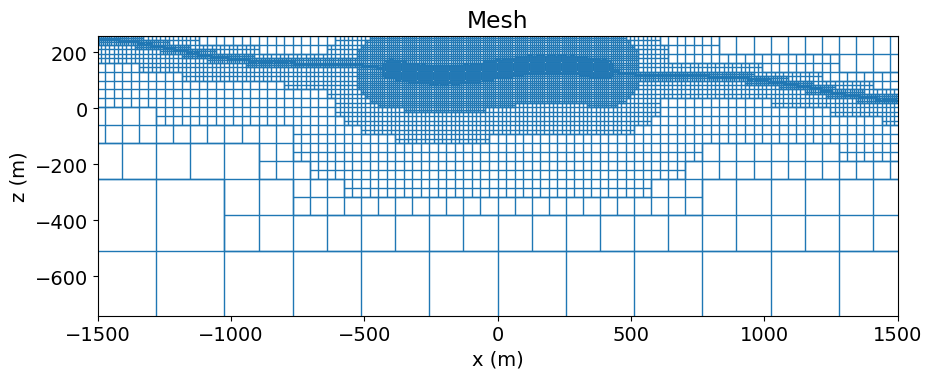

In [146]:
fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_axes([0.14, 0.17, 0.8, 0.7])
mesh.plot_grid(ax=ax1, linewidth=1)
ax1.grid(False)
ax1.set_xlim(-1500, 1500)
ax1.set_ylim(np.max(z_topo) - 1000, np.max(z_topo))
ax1.set_title("Mesh")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

plt.show()


In [147]:
# Indices of the active mesh cells from topography (e.g. cells below surface)
active_cells = active_from_xyz(mesh, topo_2d)

# number of active cells
n_active = np.sum(active_cells)


In [148]:
air_resistivity = 1/1e-8
background_resistivity = 1/1e-2
conductor_resistivity = 1/1e-1
resistor_resistivity = 1/1e-3


In [149]:
# Define resistivity model
resistivity_model = background_resistivity * np.ones(n_active)

ind_conductor = model_builder.get_indices_sphere(
    np.r_[-120.0, 40.0], 60.0, mesh.cell_centers[active_cells, :]
)
resistivity_model[ind_conductor] = conductor_resistivity

ind_resistor = model_builder.get_indices_sphere(
    np.r_[120.0, 72.0], 60.0, mesh.cell_centers[active_cells, :]
)
resistivity_model[ind_resistor] = resistor_resistivity

# Define log-resistivity model
log_resistivity_model = np.log(resistivity_model)


In [150]:
# Resistivity map. Model parameters are log-resistivities for all active cells.
log_resistivity_map = maps.InjectActiveCells(
    mesh, active_cells, air_resistivity
) * maps.ExpMap(nP=n_active)


In [151]:
# Generate a mapping to ignore inactice cells in plot
plotting_map = maps.InjectActiveCells(mesh, active_cells, np.nan)


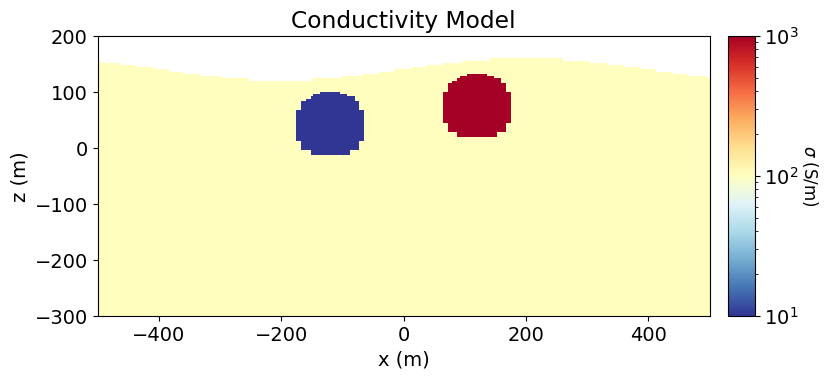

In [152]:
fig = plt.figure(figsize=(9, 4))

norm = LogNorm(vmin=conductor_resistivity, vmax=resistor_resistivity)

ax1 = fig.add_axes([0.14, 0.17, 0.68, 0.7])
mesh.plot_image(
    plotting_map * resistivity_model,
    ax=ax1,
    grid=False,
    pcolor_opts={"norm": norm, "cmap": mpl.cm.RdYlBu_r},
)
ax1.set_xlim(-500, 500)
ax1.set_ylim(-300, 200)
ax1.set_title("Conductivity Model")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

ax2 = fig.add_axes([0.84, 0.17, 0.03, 0.7])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.RdYlBu_r
)
cbar.set_label(r"$\sigma$ (S/m)", rotation=270, labelpad=15, size=12)

plt.show()


In [153]:
survey.drape_electrodes_on_topography(mesh, active_cells, option="top")


In [154]:
def forward_torch(m, dtype="rho"):
    cfg = SimpegConfig()
    cfg.torch_is_active = True
    cfg.device = 'cpu'
    cfg.dtype = torch.float64
    cfg.solver = "superlu"

    simulation_res = dc.simulation_2d.Simulation2DNodal(
        mesh, survey=survey, rhoMap=log_resistivity_map
    )

    M = torch.log(m)
    dc_data = simulation_res.make_synthetic_data(M, relative_error=0)
    if dtype == "rho":
        dobs = apparent_resistivity_from_voltage(survey, dc_data.dobs)
    else:
        dobs = dc_data.dobs
    return dobs

def forward_vanilla(model, dtype="rho"):
    cfg = SimpegConfig()
    cfg.torch_is_active = False
    simulation_res = dc.simulation_2d.Simulation2DNodal(
        mesh, survey=survey, rhoMap=log_resistivity_map
    )
    dc_data = simulation_res.make_synthetic_data(model, relative_error=0)
    if dtype == "rho":
        dobs = apparent_resistivity_from_voltage(survey, dc_data.dobs)
    return dobs, simulation_res


In [155]:
dpred_vanilla_res = forward_vanilla(log_resistivity_model)[0]
simulation_vanilla_res = forward_vanilla(log_resistivity_model)[1]


c:\Users\eaqm1\anaconda3\envs\simpeg-pytorch\lib\site-packages\SimPEG\electromagnetics\static\resistivity\simulation_2d.py:894: RuntimeWarning: invalid value encountered in divide
  r_hat = r_vec / r[:, None]
c:\Users\eaqm1\anaconda3\envs\simpeg-pytorch\lib\site-packages\SimPEG\electromagnetics\static\resistivity\simulation_2d.py:913: RuntimeWarning: invalid value encountered in divide
  alpha[not_top] = (ky * k1e(ky * r) / k0e(ky * r) * r_dot_n)[not_top]
c:\Users\eaqm1\anaconda3\envs\simpeg-pytorch\lib\site-packages\SimPEG\utils\solver_utils.py:116: UserWarning: is_symmetric is not a valid keyword for splu and will be ignored
  warnings.warn(
c:\Users\eaqm1\anaconda3\envs\simpeg-pytorch\lib\site-packages\SimPEG\utils\solver_utils.py:116: UserWarning: is_positive_definite is not a valid keyword for splu and will be ignored
  warnings.warn(


In [156]:
m_true = torch.tensor(np.exp(log_resistivity_model), requires_grad=True)
dobs_torch = forward_torch(m_true)
loss = dobs_torch.sum()
loss.backward()
J_aggregate_torch = abs(m_true.grad.detach().numpy())


In [157]:
plotting_map = maps.InjectActiveCells(mesh, active_cells, np.nan)
cfg = SimpegConfig()
cfg.torch_is_active = False


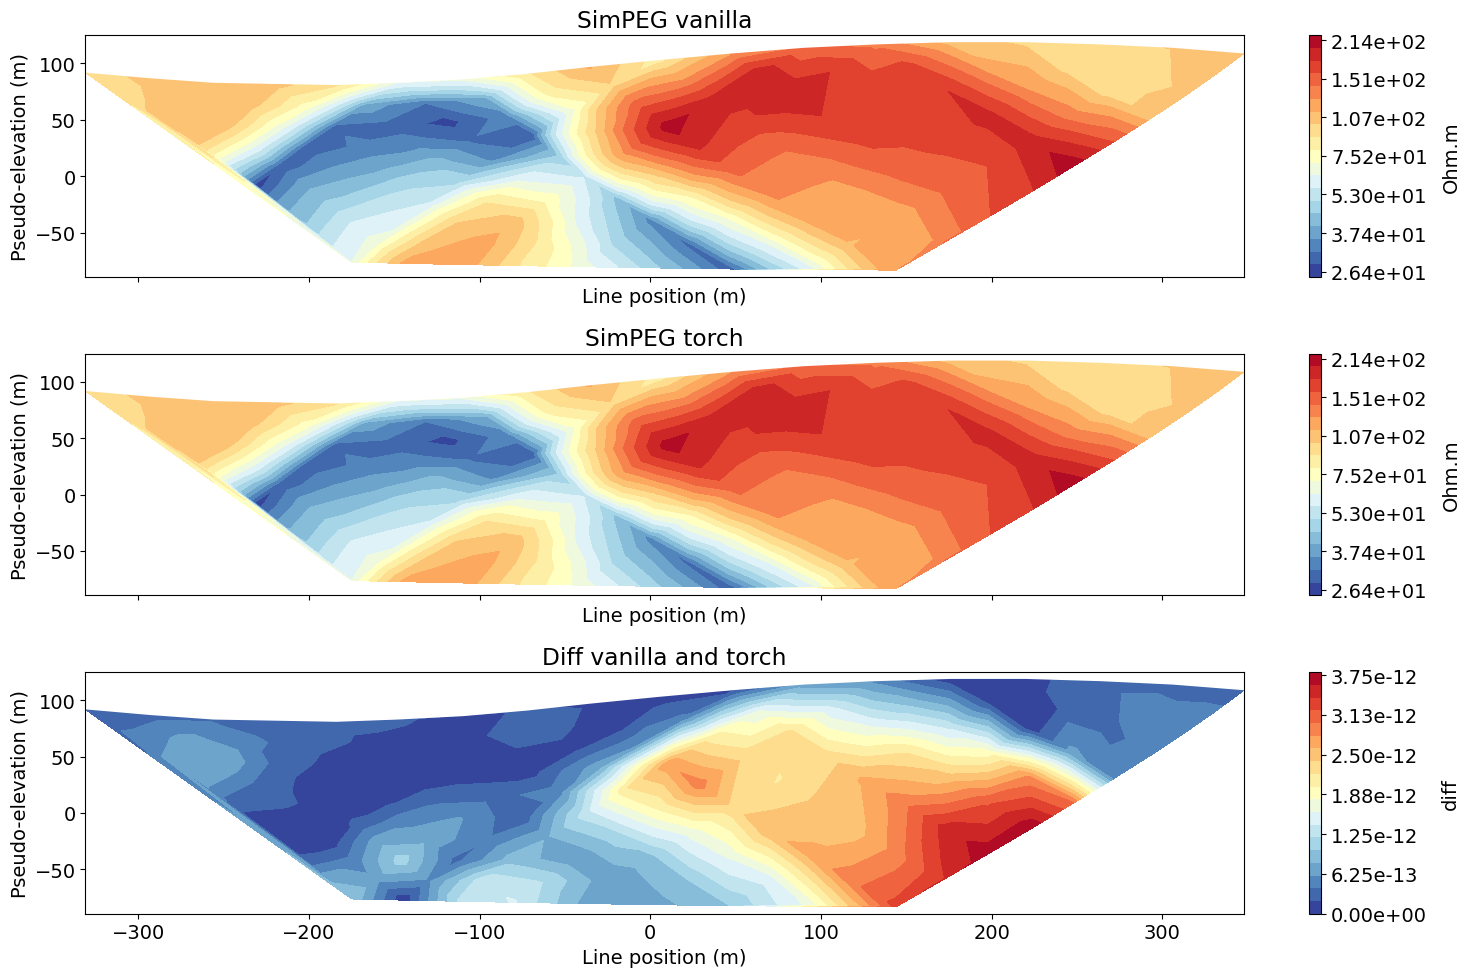

In [160]:
apparent_rho_vanilla = dpred_vanilla_res
apparent_rho_torch =dobs_torch.detach().numpy()
diff_torch_vanilla = abs(apparent_rho_torch-apparent_rho_vanilla)

data_plot = [apparent_rho_vanilla, apparent_rho_torch, diff_torch_vanilla]
title_plot = ["SimPEG vanilla", "SimPEG torch", "Diff vanilla and torch"]
cbar_label = ["Ohm.m", "Ohm.m", "diff"]
scale_plot= ["log", "log", "linear"]
fig, ax = plt.subplots(3,1,figsize=(15,10), sharex=True)

for idx, d in enumerate(data_plot):
    ax[idx].set_title(title_plot[idx])
    plot_pseudosection(
        survey,
        dobs=d,
        plot_type="contourf",
        ax=ax[idx],
        scale=scale_plot[idx],
        cbar_label=cbar_label[idx],
        mask_topography=True,
        contourf_opts={"levels": 20, "cmap": mpl.cm.RdYlBu_r}
    )
plt.tight_layout()


In [161]:
plotting_map = maps.InjectActiveCells(mesh, active_cells, np.nan)
cfg = SimpegConfig()
cfg.torch_is_active = False


In [162]:
fields = simulation_vanilla_res.fields(log_resistivity_model)
J_full_vanilla = simulation_vanilla_res._Jtvec(log_resistivity_model, f=fields)
J_aggregated_vanilla = abs(J_full_vanilla.sum(axis=1))


c:\Users\eaqm1\anaconda3\envs\simpeg-pytorch\lib\site-packages\SimPEG\utils\solver_utils.py:116: UserWarning: is_symmetric is not a valid keyword for splu and will be ignored
  warnings.warn(
c:\Users\eaqm1\anaconda3\envs\simpeg-pytorch\lib\site-packages\SimPEG\utils\solver_utils.py:116: UserWarning: is_positive_definite is not a valid keyword for splu and will be ignored
  warnings.warn(


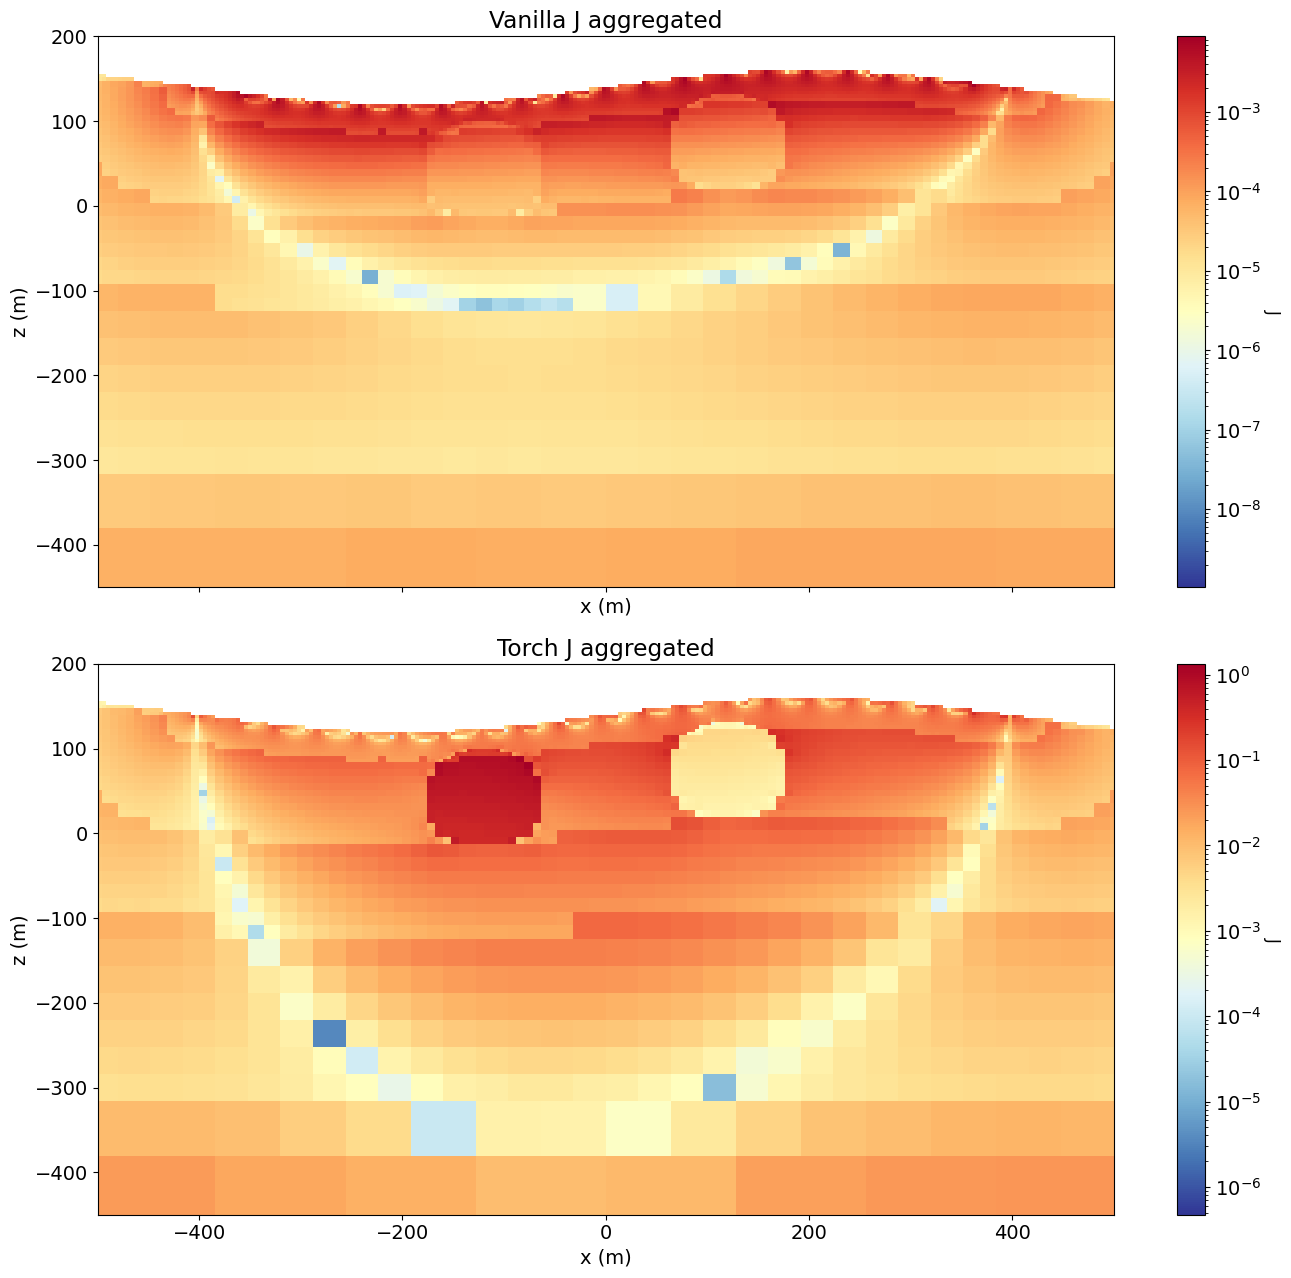

In [164]:
fig, ax = plt.subplots(2,1,figsize=(14, 13), sharex=True)

norm_vanilla = LogNorm(vmin=J_aggregated_vanilla.min(), vmax=J_aggregated_vanilla.max())
norm_torch = LogNorm(vmin=J_aggregate_torch.min(), vmax=J_aggregate_torch.max())

J_aggregate = [J_aggregated_vanilla, J_aggregate_torch]
norm =[norm_vanilla, norm_torch]
title_J_plots = ["Vanilla J aggregated", "Torch J aggregated"]

for idx, J in enumerate(J_aggregate):
    ax[idx].set_title(title_J_plots[idx])
    im = mesh.plot_image(
        plotting_map * J,
        ax=ax[idx],
        grid=False,
        pcolor_opts={"norm": norm[idx], "cmap": mpl.cm.RdYlBu_r},
    )
    ax[idx].set_xlim(-500, 500)
    ax[idx].set_ylim(-450, 200)
    ax[idx].set_xlabel("x (m)")
    ax[idx].set_ylabel("z (m)")

    # agregar la barra de color a la derecha de cada subplot
    cbar = fig.colorbar(im[0], ax=ax[idx], orientation="vertical")
    cbar.set_label(r"J", rotation=270, labelpad=15, size=12)

plt.tight_layout()
